# Notebook 15 — MJO SSL Temporal 2D Encoder
**Project:** ENSO-BSISO SSL — MJO Extension  
**Author:** Jiayi (jh9141@nyu.edu)

Self-supervised temporal 2D encoder for MJO. Pairs defined by **temporal proximity only** (no RMM/ENSO labels). Exact analog of `nb08` (BSISO SSL), with two key adaptations:

1. **20–90 day Lanczos bandpass** (Q4 = B from Session 20) — standard MJO band, replaces nb08's 25-day lowpass.  
2. **All-year continuous data** — bandpass applied to the full 1979–2023 time series (no per-year fragmentation, unlike BSISO MJJAS).

## Setup (locked decisions)

| Knob | Value | Source |
|---|---|---|
| Input | `X_MJO.npy`, shape `(N, 3, 1, 180)` | nb13 |
| Embedding dim | 2 (no L2 norm) | nb07c/nb08 lesson |
| Loss | raw dot product InfoNCE | nb08 |
| Temperature τ | 0.5 | nb08 |
| Weight decay | 1e-4 | nb08 |
| Optimizer | Adam, lr=1e-3, cosine→1e-5 | nb08 |
| Epochs | 50 | nb08 |
| Architecture | Conv2d kernel=(1,3), pool=(1,2) | Q5 |
| **Bandpass** | **Lanczos 20–90 day** (low=20d, high=90d, half_w=90) | **Q4 = B** |
| Edge drop | 90 days from each end of full record | filter edge effects |
| Positive pair | anchor d, positive in [d−3, d+3] \ {d}, same year | nb08 |
| Year split | every 5th year held out | nb04/nb07c/nb08 |

## Outputs

- `MJO/checkpoints/encoder_mjo_ssl_final.pth`
- `MJO/data/processed/X_MJO_bp20_90.npy` — bandpassed input (saved for reuse by nb16)
- `MJO/data/processed/labels_aligned_mjo_bp20_90.csv` — labels after edge drops
- `MJO/results/ssl/embeddings.npy`, `training_curves.png`, `embedding_2d_overview.png`, `month_clustering_check.png`, `linear_probe_results.json`, `enso_displacement.png`, `mjo_ssl_summary.md`

## Runtime
Bandpass: ~2 min. Training: ~30–45 min on T4. Total ~35–50 min.

---

## Cell 1 — Mount Drive + Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d

EMBEDDING_DIM   = 2
RUN_TAG         = 'mjo_ssl'
TEMPERATURE     = 0.5
EPOCHS          = 50
BATCH_SIZE      = 64
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
MAX_DELTA       = 3        # positive pair window: [d-3, d+3] \ {d}, same year
BP_LOW_DAYS     = 20       # passes periods ≥ 20 days (removes synoptic noise)
BP_HIGH_DAYS    = 90       # passes periods ≤ 90 days (removes ENSO and seasonal residual)
BP_HALF_W       = 90       # filter half-window in days (filter length = 181)
EDGE_DROP_DAYS  = BP_HALF_W

PROJECT_DIR    = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR        = f'{PROJECT_DIR}/MJO'
PROCESSED_DIR  = f'{MJO_DIR}/data/processed'
CHECKPOINT_DIR = f'{MJO_DIR}/checkpoints'
RESULTS_DIR    = f'{MJO_DIR}/results/ssl'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_FILE         = 'X_MJO.npy'
LABELS_FILE    = 'labels_aligned_mjo.csv'
X_BP_FILE      = 'X_MJO_bp20_90.npy'
LABELS_BP_FILE = 'labels_aligned_mjo_bp20_90.csv'

# Clear stale outputs from any prior runs
# WARNING: this deletes the trained checkpoint AND everything in RESULTS_DIR,
# including embeddings.npy. Leave False unless you intend a full re-train —
# otherwise a fresh runtime has nothing for the diagnostic cells to reload.
CLEAR_STALE = False
stale = (glob.glob(f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_*.pth') +
         glob.glob(f'{CHECKPOINT_DIR}/training_history_{RUN_TAG}.json') +
         glob.glob(f'{RESULTS_DIR}/*'))
if CLEAR_STALE:
    for p in stale:
        try: os.remove(p)
        except (IsADirectoryError, FileNotFoundError): pass
    print(f'Cleared {len(stale)} stale files from previous runs.')
else:
    print(f'CLEAR_STALE=False -> kept {len(stale)} existing files '
          f'(set True before a full re-train).')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:           {device}')
print(f'Embedding dim:    {EMBEDDING_DIM} (no L2 normalization)')
print(f'Loss:             raw dot product InfoNCE (τ={TEMPERATURE})')
print(f'Bandpass:         Lanczos {BP_LOW_DAYS}–{BP_HIGH_DAYS} d  (half_w={BP_HALF_W}, edge drop ±{EDGE_DROP_DAYS} d)')
print(f'Positive pair:    [d−{MAX_DELTA}, d+{MAX_DELTA}] \\ {{d}}, same year')
print(f'Run tag:          {RUN_TAG}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CLEAR_STALE=False -> kept 0 existing files (set True before a full re-train).
Device:           cuda
Embedding dim:    2 (no L2 normalization)
Loss:             raw dot product InfoNCE (τ=0.5)
Bandpass:         Lanczos 20–90 d  (half_w=90, edge drop ±90 d)
Positive pair:    [d−3, d+3] \ {d}, same year
Run tag:          mjo_ssl


## Cell 2 — Load Data

In [ ]:
X      = np.load(f'{PROCESSED_DIR}/{X_FILE}')
labels = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_FILE}', parse_dates=['date'])

print(f'X shape:  {X.shape}  (expect (N, 3, 1, 180))')
print(f'Labels:   {len(labels)} rows')
assert X.shape[0] == len(labels), 'X / labels length mismatch'
assert X.shape[1:] == (3, 1, 180), f'Unexpected shape {X.shape[1:]}'

print(f'\nDate range:    {labels["date"].min().date()} to {labels["date"].max().date()}')
print(f'Month coverage: {sorted(labels["date"].dt.month.unique())}')

X shape:  (16436, 3, 1, 180)  (expect (N, 3, 1, 180))
Labels:   16436 rows

Date range:    1979-01-01 to 2023-12-31
Month coverage: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


## Cell 3 — Lanczos 20–90 day Bandpass

**Filter design** (Q4 = B):
- Bandpass = lowpass(20d) − lowpass(90d) → passes periods in (20, 90) d.
  - Lowpass(20d) keeps periods > 20d (loose).
  - Lowpass(90d) keeps periods > 90d (strict).
  - Difference keeps periods in (20, 90) d — the standard MJO band.
- Half-window 90 days → filter length 181 (sufficient for the 90-day cutoff).
- Applied to the **full continuous time series** (all-year data, unlike BSISO MJJAS per-year).
- Drop first/last 90 days only (negligible loss out of ~16,400 days).

Filter length:    181 taps (half_w=90)
Sum of weights:   -0.000000  (should be ≈ 0 — bandpass has zero DC gain)
Peak |weight|:    0.0780


/tmp/ipykernel_577/2860183132.py:5: RuntimeWarning: invalid value encountered in divide
  h = np.where(k == 0, 2*fc, np.sin(2*np.pi*fc*k) / (np.pi*k))
/tmp/ipykernel_577/2860183132.py:6: RuntimeWarning: invalid value encountered in divide
  sigma = np.where(k == 0, 1.0, np.sin(np.pi*k/half_window) / (np.pi*k/half_window))


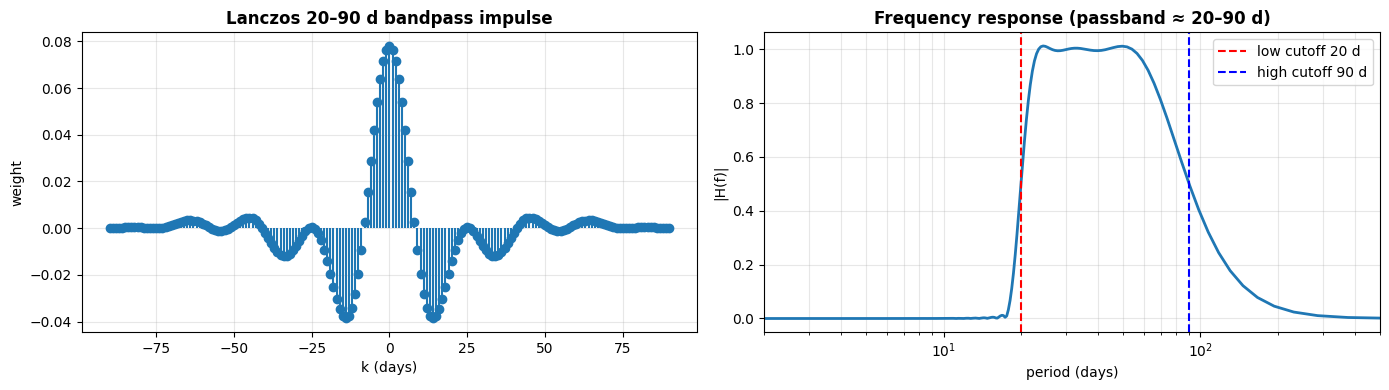


Applying bandpass to full continuous time series ...

Before drop: 16436 samples
After drop:  16256 samples  (98.9%)
Date range:  1979-04-01 to 2023-10-02

Saved: X_MJO_bp20_90.npy shape (16256, 3, 1, 180)
Saved: labels_aligned_mjo_bp20_90.csv  rows 16256

Variance (channel-mean over space) — raw vs bandpassed:
  u850: raw var=0.9870, bp var=0.3964  (ratio=40.16%)
  OLR: raw var=0.9974, bp var=0.3050  (ratio=30.58%)
  u200: raw var=1.0173, bp var=0.4402  (ratio=43.27%)


In [ ]:
def lanczos_lowpass_weights(cutoff_days, half_window):
    """Lanczos-windowed sinc lowpass. Passes periods > cutoff_days."""
    k = np.arange(-half_window, half_window + 1)
    fc = 1.0 / cutoff_days
    h = np.where(k == 0, 2*fc, np.sin(2*np.pi*fc*k) / (np.pi*k))
    sigma = np.where(k == 0, 1.0, np.sin(np.pi*k/half_window) / (np.pi*k/half_window))
    w = h * sigma
    w /= w.sum()
    return w

def lanczos_bandpass_weights(low_period, high_period, half_window):
    """Bandpass passing periods in (low_period, high_period). low < high in days."""
    w_low  = lanczos_lowpass_weights(low_period,  half_window)
    w_high = lanczos_lowpass_weights(high_period, half_window)
    return w_low - w_high

weights = lanczos_bandpass_weights(BP_LOW_DAYS, BP_HIGH_DAYS, BP_HALF_W)
print(f'Filter length:    {len(weights)} taps (half_w={BP_HALF_W})')
print(f'Sum of weights:   {weights.sum():.6f}  (should be ≈ 0 — bandpass has zero DC gain)')
print(f'Peak |weight|:    {np.abs(weights).max():.4f}')

# Frequency response (sanity)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].stem(np.arange(-BP_HALF_W, BP_HALF_W+1), weights, basefmt=' ')
axes[0].set_xlabel('k (days)'); axes[0].set_ylabel('weight')
axes[0].set_title(f'Lanczos {BP_LOW_DAYS}–{BP_HIGH_DAYS} d bandpass impulse', fontweight='bold')
axes[0].grid(alpha=0.3)

freqs = np.linspace(0.001, 0.5, 600)
k_arr = np.arange(-BP_HALF_W, BP_HALF_W+1)
response = np.abs(np.array([np.sum(weights * np.exp(-2j*np.pi*f*k_arr)) for f in freqs]))
periods = 1.0 / freqs
axes[1].plot(periods, response, linewidth=2)
axes[1].axvline(BP_LOW_DAYS,  color='red',  linestyle='--', label=f'low cutoff {BP_LOW_DAYS} d')
axes[1].axvline(BP_HIGH_DAYS, color='blue', linestyle='--', label=f'high cutoff {BP_HIGH_DAYS} d')
axes[1].set_xscale('log'); axes[1].set_xlabel('period (days)'); axes[1].set_ylabel('|H(f)|')
axes[1].set_title('Frequency response (passband ≈ 20–90 d)', fontweight='bold')
axes[1].set_xlim(2, 500); axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/bandpass_filter_response.png', dpi=130, bbox_inches='tight')
plt.show()

# Apply filter to full continuous record
print('\nApplying bandpass to full continuous time series ...')
X_filt = convolve1d(X.astype(np.float64), weights, axis=0, mode='reflect').astype(np.float32)

# Drop edges
T = len(X)
mask_keep = np.zeros(T, dtype=bool)
mask_keep[EDGE_DROP_DAYS : T - EDGE_DROP_DAYS] = True

X_bp = X_filt[mask_keep]
labels_bp = labels.loc[mask_keep].reset_index(drop=True)

print(f'\nBefore drop: {T} samples')
print(f'After drop:  {len(X_bp)} samples  ({100*len(X_bp)/T:.1f}%)')
print(f'Date range:  {labels_bp["date"].min().date()} to {labels_bp["date"].max().date()}')

np.save(f'{PROCESSED_DIR}/{X_BP_FILE}', X_bp)
labels_bp.to_csv(f'{PROCESSED_DIR}/{LABELS_BP_FILE}', index=False)
print(f'\nSaved: {X_BP_FILE} shape {X_bp.shape}')
print(f'Saved: {LABELS_BP_FILE}  rows {len(labels_bp)}')

# Variance comparison
print('\nVariance (channel-mean over space) — raw vs bandpassed:')
for ch, name in enumerate(['u850', 'OLR', 'u200']):
    v_raw = X[mask_keep, ch].var()
    v_bp  = X_bp[:, ch].var()
    print(f'  {name}: raw var={v_raw:.4f}, bp var={v_bp:.4f}  (ratio={v_bp/v_raw:.2%})')

## Cell 4 — Year-Based Train/Val Split (on Bandpassed Data)

In [ ]:
all_years = sorted(labels_bp['date'].dt.year.unique())
val_years = all_years[::5]
train_years = [y for y in all_years if y not in val_years]

year_col = labels_bp['date'].dt.year
train_idx = labels_bp.index[year_col.isin(train_years)].values
val_idx   = labels_bp.index[year_col.isin(val_years)].values

print(f'Val years ({len(val_years)}): {val_years}')
print(f'Train: {len(train_idx)} samples ({100*len(train_idx)/len(labels_bp):.1f}%)')
print(f'Val:   {len(val_idx)} samples ({100*len(val_idx)/len(labels_bp):.1f}%)')
print(f'\nENSO distribution (val):')
print(labels_bp.loc[val_idx, 'enso_category'].value_counts())

Val years (9): [np.int32(1979), np.int32(1984), np.int32(1989), np.int32(1994), np.int32(1999), np.int32(2004), np.int32(2009), np.int32(2014), np.int32(2019)]
Train: 13059 samples (80.3%)
Val:   3197 samples (19.7%)

ENSO distribution (val):
enso_category
Neutral    1462
La Nina    1002
El Nino     733
Name: count, dtype: int64


## Cell 5 — SSL Temporal Pair Sampler + Dataset

Same logic as nb08. Pairs defined by temporal proximity only — model never sees RMM phase or ENSO during training.

In [ ]:
class TemporalPairSampler:
    def __init__(self, labels_df, allowed_indices, max_delta=3):
        self.labels = labels_df
        self.allowed_set = set(int(i) for i in allowed_indices)
        self.max_delta = max_delta
        sub = labels_df.loc[list(self.allowed_set)]
        self.date_to_idx = {pd.Timestamp(d): int(i)
                            for d, i in zip(sub['date'].values, sub.index.values)}

    def sample_positive_pair(self, anchor_idx):
        anchor_date = self.labels.loc[anchor_idx, 'date']
        anchor_year = anchor_date.year
        candidates = []
        for delta in range(-self.max_delta, self.max_delta + 1):
            if delta == 0: continue
            target = anchor_date + pd.Timedelta(days=delta)
            if target.year != anchor_year: continue
            key = pd.Timestamp(target)
            if key in self.date_to_idx:
                candidates.append(self.date_to_idx[key])
        if not candidates:
            return anchor_idx, anchor_idx
        return anchor_idx, int(np.random.choice(candidates))


class SSLTemporalDataset(Dataset):
    def __init__(self, X_data, labels_df, train_indices, max_delta=3, mode='train', n_val_pairs=1000):
        self.X = X_data
        self.labels = labels_df
        self.train_indices = np.asarray(train_indices)
        self.sampler = TemporalPairSampler(labels_df, train_indices, max_delta)
        self.mode = mode
        if mode == 'val':
            rng = np.random.default_rng(42)
            self.val_pairs = []
            for idx in rng.choice(self.train_indices,
                                  size=min(n_val_pairs * 2, len(self.train_indices)), replace=False):
                a, b = self.sampler.sample_positive_pair(int(idx))
                if a != b: self.val_pairs.append((a, b))
                if len(self.val_pairs) >= n_val_pairs: break

    def __len__(self):
        return len(self.train_indices) if self.mode == 'train' else len(self.val_pairs)

    def __getitem__(self, idx):
        if self.mode == 'train':
            anchor = int(self.train_indices[idx])
            a, b = self.sampler.sample_positive_pair(anchor)
        else:
            a, b = self.val_pairs[idx]
        return torch.from_numpy(self.X[a]).float(), torch.from_numpy(self.X[b]).float()


train_dataset = SSLTemporalDataset(X_bp, labels_bp, train_idx, max_delta=MAX_DELTA, mode='train')
val_dataset   = SSLTemporalDataset(X_bp, labels_bp, val_idx,   max_delta=MAX_DELTA, mode='val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} items → {len(train_loader)} batches/epoch')
print(f'Val:   {len(val_dataset)} pairs  → {len(val_loader)} batches')

# Sampler sanity
n_zero = 0
print('\nSample positive pairs (anchor → positive):')
for i in range(10):
    a, b = train_dataset.sampler.sample_positive_pair(int(train_idx[i]))
    da = labels_bp.loc[a, 'date']; db = labels_bp.loc[b, 'date']
    delta_d = (db - da).days
    if delta_d == 0: n_zero += 1
    print(f'  {da.date()} (P{labels_bp.loc[a, "phase"]}) → {db.date()} (P{labels_bp.loc[b, "phase"]})  Δ={delta_d}d')
assert n_zero == 0, f'{n_zero}/10 pairs are (anchor, anchor) — sampler broken.'
assert len(val_dataset) > 0, 'val_dataset is empty.'
print('\n✓ Sampler healthy.')

Train: 13059 items → 205 batches/epoch
Val:   1000 pairs  → 16 batches

Sample positive pairs (anchor → positive):
  1980-01-01 (P4) → 1980-01-02 (P4)  Δ=1d
  1980-01-02 (P4) → 1980-01-05 (P5)  Δ=3d
  1980-01-03 (P5) → 1980-01-02 (P4)  Δ=-1d
  1980-01-04 (P5) → 1980-01-05 (P5)  Δ=1d
  1980-01-05 (P5) → 1980-01-08 (P5)  Δ=3d
  1980-01-06 (P5) → 1980-01-03 (P5)  Δ=-3d
  1980-01-07 (P5) → 1980-01-04 (P5)  Δ=-3d
  1980-01-08 (P5) → 1980-01-07 (P5)  Δ=-1d
  1980-01-09 (P5) → 1980-01-11 (P5)  Δ=2d
  1980-01-10 (P5) → 1980-01-09 (P5)  Δ=-1d

✓ Sampler healthy.


## Cell 6 — Encoder + Loss (same as nb14)

In [ ]:
class MJOEncoderNoL2(nn.Module):
    def __init__(self, embedding_dim=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  16, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d((1, 2))
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d((1, 2))
        self.conv3 = nn.Conv2d(32, 32, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn3   = nn.BatchNorm2d(32)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc          = nn.Linear(32, embedding_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).view(x.size(0), -1)
        return self.fc(x)


def InfoNCE_loss_raw(z_A, z_B, temperature):
    sim_matrix = torch.matmul(z_A, z_B.T) / temperature
    labels_ = torch.arange(z_A.size(0), device=z_A.device)
    return F.cross_entropy(sim_matrix, labels_)

encoder = MJOEncoderNoL2(embedding_dim=EMBEDDING_DIM).to(device)
optimizer = optim.Adam(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f'Parameters: {sum(p.numel() for p in encoder.parameters()):,}')
print(f'Training:   {EPOCHS} epochs, batch {BATCH_SIZE}, τ={TEMPERATURE}, weight_decay={WEIGHT_DECAY}')

Parameters: 4,978
Training:   50 epochs, batch 64, τ=0.5, weight_decay=0.0001


## Cell 7 — Training Loop

In [ ]:
from tqdm.notebook import tqdm
assert len(train_loader) > 0 and len(val_loader) > 0

history = {'train_loss': [], 'val_loss': [], 'epoch_time': [],
           'mean_norm': [], 'std_norm': [], 'max_norm': []}

for epoch in range(EPOCHS):
    t0 = time.time()
    encoder.train()
    train_loss = 0.0
    epoch_norms = []
    pbar = tqdm(train_loader, desc=f'ep {epoch+1}/{EPOCHS}', leave=False)
    for fA, fB in pbar:
        fA = fA.to(device, non_blocking=True); fB = fB.to(device, non_blocking=True)
        zA = encoder(fA); zB = encoder(fB)
        with torch.no_grad():
            epoch_norms.extend(zA.norm(dim=1).cpu().numpy().tolist())
            epoch_norms.extend(zB.norm(dim=1).cpu().numpy().tolist())
        loss = InfoNCE_loss_raw(zA, zB, temperature=TEMPERATURE)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    train_loss /= len(train_loader)

    encoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for fA, fB in val_loader:
            fA = fA.to(device, non_blocking=True); fB = fB.to(device, non_blocking=True)
            zA = encoder(fA); zB = encoder(fB)
            val_loss += InfoNCE_loss_raw(zA, zB, temperature=TEMPERATURE).item()
    val_loss = val_loss / len(val_loader)
    scheduler.step()

    en = np.array(epoch_norms); et = time.time() - t0
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['epoch_time'].append(et)
    history['mean_norm'].append(float(en.mean())); history['std_norm'].append(float(en.std()))
    history['max_norm'].append(float(en.max()))
    print(f'ep {epoch+1:2d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  '
          f'norm μ={en.mean():.3f} σ={en.std():.3f} max={en.max():.2f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}  time={et:.1f}s')

    if (epoch + 1) % 10 == 0:
        torch.save({'epoch': epoch+1, 'model_state_dict': encoder.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_loss': train_loss, 'val_loss': val_loss},
                   f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_epoch_{epoch+1}.pth')

torch.save(encoder.state_dict(), f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_final.pth')
with open(f'{CHECKPOINT_DIR}/training_history_{RUN_TAG}.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nTraining complete. Total time: {sum(history["epoch_time"])/60:.1f} min')
print(f'Final mean norm: {history["mean_norm"][-1]:.3f}  max norm: {history["max_norm"][-1]:.2f}')

ep 1/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep  1/50  train=3.7188  val=3.6764  norm μ=0.563 σ=0.445 max=3.41  lr=9.99e-04  time=6.2s


ep 2/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep  2/50  train=3.6296  val=3.6513  norm μ=0.685 σ=0.437 max=1.85  lr=9.96e-04  time=3.5s


ep 3/50:   0%|          | 0/205 [00:00<?, ?it/s]

...

ep 48/50  train=3.0125  val=3.1275  norm μ=1.201 σ=0.447 max=2.42  lr=1.39e-05  time=4.5s


ep 49/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep 49/50  train=3.0135  val=3.1198  norm μ=1.200 σ=0.447 max=2.36  lr=1.10e-05  time=5.1s


ep 50/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep 50/50  train=3.0140  val=3.1223  norm μ=1.202 σ=0.447 max=2.52  lr=1.00e-05  time=3.7s

Training complete. Total time: 3.3 min
Final mean norm: 1.202  max norm: 2.52


## Cell 8 — Training Curves

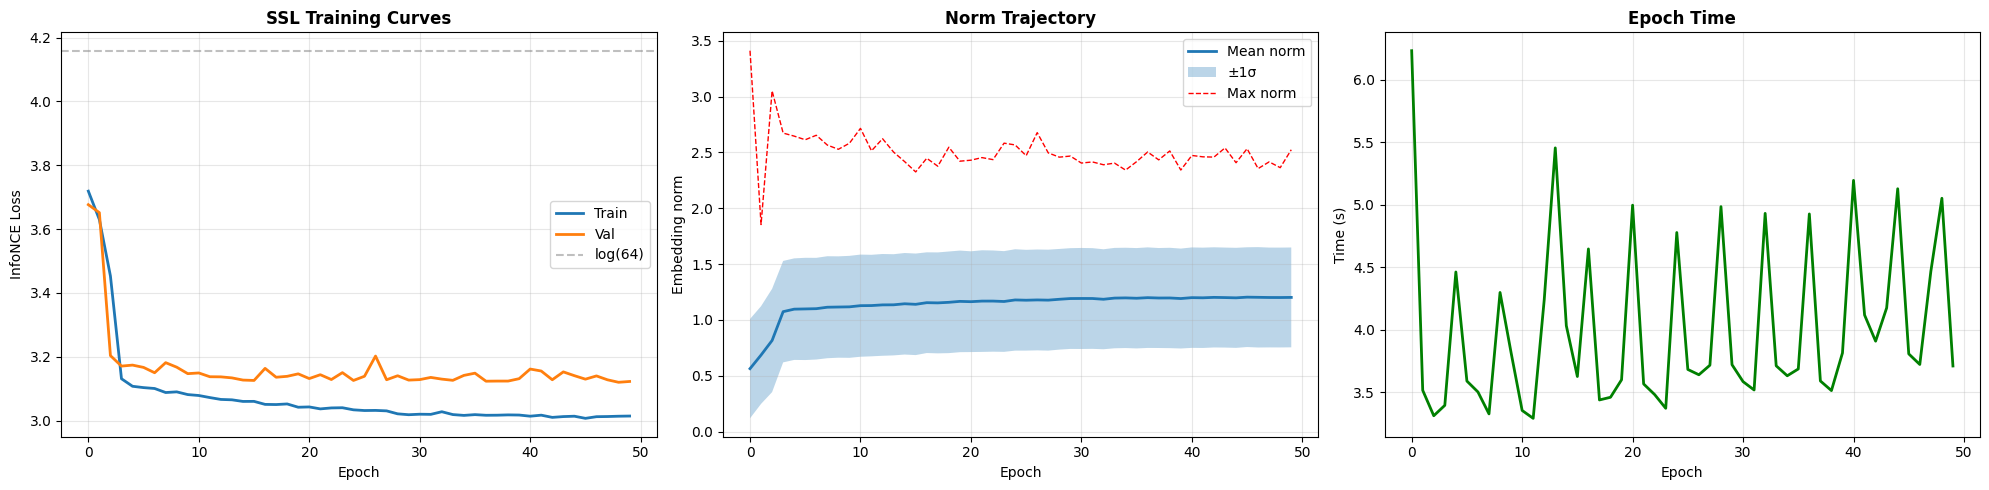


✓ Norms stable (max ever = 3.41)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].axhline(np.log(64), color='gray', linestyle='--', alpha=0.5, label='log(64)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('SSL Training Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['mean_norm'], label='Mean norm', linewidth=2)
axes[1].fill_between(range(len(history['mean_norm'])),
                     np.array(history['mean_norm']) - np.array(history['std_norm']),
                     np.array(history['mean_norm']) + np.array(history['std_norm']),
                     alpha=0.3, label='±1σ')
axes[1].plot(history['max_norm'], label='Max norm', color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Embedding norm')
axes[1].set_title('Norm Trajectory', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch_time'], color='green', linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Time (s)')
axes[2].set_title('Epoch Time', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
if max(history['max_norm']) > 100:
    print('\n⚠️  Norm explosion. Increase WEIGHT_DECAY.')
else:
    print(f'\n✓ Norms stable (max ever = {max(history["max_norm"]):.2f})')

## Cell 9 — Extract Embeddings

In [ ]:
encoder.eval()
embeddings_2d = np.zeros((len(X_bp), EMBEDDING_DIM), dtype=np.float32)
with torch.no_grad():
    for start in range(0, len(X_bp), 128):
        end = min(start + 128, len(X_bp))
        batch = torch.from_numpy(X_bp[start:end]).float().to(device)
        embeddings_2d[start:end] = encoder(batch).cpu().numpy()

np.save(f'{RESULTS_DIR}/embeddings.npy', embeddings_2d)
norms = np.linalg.norm(embeddings_2d, axis=1)
angles = np.arctan2(embeddings_2d[:, 1], embeddings_2d[:, 0])
print(f'Embeddings shape: {embeddings_2d.shape}')
print(f'Norm:  min={norms.min():.3f}  max={norms.max():.3f}  mean={norms.mean():.3f}  std={norms.std():.3f}')
print(f'Angle: spread = {angles.max() - angles.min():.3f} rad')

Embeddings shape: (16256, 2)
Norm:  min=0.009  max=2.541  mean=1.185  std=0.449
Angle: spread = 6.282 rad


## Cell 9r — Recovery: rebuild `embeddings.npy` without re-training

Prints an inventory of what survived in `CHECKPOINT_DIR`, `RESULTS_DIR`,
`PROCESSED_DIR` and the shared `results/enso_marginal/` folder, then — if any
`encoder_{RUN_TAG}_*.pth` is still there — reloads it, re-extracts the embeddings
from the **cached** bandpassed `X_bp` (no Lanczos recompute, ~1 min) and writes
`embeddings.npy` back. `embeddings_2d` and `labels_bp` are left in memory, so
Cell 10b then finds them on tier 1.

Needs only **Cell 1** (paths, `device`) and **Cell 6** (the `MJOEncoderNoL2` class).
If no checkpoint survived it says so and prints the two remaining options.

In [ ]:
# ── Cell 9r — Inventory + rebuild embeddings.npy WITHOUT re-training ─────────
# Run this when RESULTS_DIR was wiped (CLEAR_STALE=True in an earlier session)
# but a checkpoint survived. Needs Cell 1 (paths) and Cell 6 (encoder class).
import os, glob
import numpy as np
import pandas as pd

print('--- what actually exists --------------------------------------------')
for _d, _pat in [(CHECKPOINT_DIR, f'encoder_{RUN_TAG}_*.pth'),
                 (RESULTS_DIR,    '*'),
                 (PROCESSED_DIR,  'X_MJO*'),
                 (f'{PROJECT_DIR}/results/enso_marginal', '*')]:
    _f = sorted(os.path.basename(p) for p in glob.glob(f'{_d}/{_pat}'))
    print(f'  {_d}/{_pat}')
    print(f'      {_f if _f else "EMPTY"}')
print('----------------------------------------------------------------------')

_final = f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_final.pth'
_epochs = sorted(glob.glob(f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_epoch_*.pth'),
                 key=lambda p: int(p.rsplit('_', 1)[1].split('.')[0]))
_use = _final if os.path.exists(_final) else (_epochs[-1] if _epochs else None)

if _use is None:
    print('\nNo checkpoint survived — the embeddings cannot be rebuilt from here.')
    print('Cheapest fix:  drive.google.com -> Trash -> restore')
    print(f'                 MJO/results/ssl/embeddings.npy   (or encoder_{RUN_TAG}_final.pth)')
    print('Otherwise:     re-run this notebook from Cell 1 with CLEAR_STALE=False.')
    print('               ~30-45 min on a T4. The bandpassed X is cached in')
    print(f'               {PROCESSED_DIR}/{X_BP_FILE}, so the Lanczos filter is not recomputed')
    print('               — but Cell 3 as written recomputes it anyway; skip Cell 3 and')
    print('               load X_bp/labels_bp from PROCESSED_DIR if you want to save that time.')
else:
    import torch
    print(f'\nUsing checkpoint: {os.path.basename(_use)}')
    X_bp      = np.load(f'{PROCESSED_DIR}/{X_BP_FILE}')          # cached — no re-filtering
    labels_bp = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_BP_FILE}', parse_dates=['date'])
    assert len(X_bp) == len(labels_bp), f'X_bp {len(X_bp)} vs labels_bp {len(labels_bp)}'
    print(f'Loaded cached X_bp {X_bp.shape} and labels_bp ({len(labels_bp)} rows)')

    encoder = MJOEncoderNoL2(embedding_dim=EMBEDDING_DIM).to(device)
    _sd = torch.load(_use, map_location=device)
    if isinstance(_sd, dict) and 'model_state_dict' in _sd:
        _sd = _sd['model_state_dict']
    encoder.load_state_dict(_sd)
    encoder.eval()

    embeddings_2d = np.zeros((len(X_bp), EMBEDDING_DIM), dtype=np.float32)
    with torch.no_grad():
        for _s in range(0, len(X_bp), 128):
            _e = min(_s + 128, len(X_bp))
            embeddings_2d[_s:_e] = encoder(
                torch.from_numpy(X_bp[_s:_e]).float().to(device)).cpu().numpy()

    os.makedirs(RESULTS_DIR, exist_ok=True)
    np.save(f'{RESULTS_DIR}/embeddings.npy', embeddings_2d)
    _n = np.linalg.norm(embeddings_2d, axis=1)
    print(f'Rebuilt {embeddings_2d.shape} -> {RESULTS_DIR}/embeddings.npy')
    print(f'Norm: min={_n.min():.3f} max={_n.max():.3f} mean={_n.mean():.3f}')
    print('embeddings_2d and labels_bp are in memory — Cell 10b will pick them up directly.')


--- what actually exists --------------------------------------------
  /content/drive/MyDrive/BSISO_SSL_Project/MJO/checkpoints/encoder_mjo_ssl_*.pth
      ['encoder_mjo_ssl_epoch_10.pth', 'encoder_mjo_ssl_epoch_20.pth', 'encoder_mjo_ssl_epoch_30.pth', 'encoder_mjo_ssl_epoch_40.pth', 'encoder_mjo_ssl_epoch_50.pth', 'encoder_mjo_ssl_final.pth']
  /content/drive/MyDrive/BSISO_SSL_Project/MJO/results/ssl/*
      ['bandpass_filter_response.png', 'embeddings.npy', 'training_curves.png']
  /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/X_MJO*
      ['X_MJO.npy', 'X_MJO_bp20_90.npy']
  /content/drive/MyDrive/BSISO_SSL_Project/results/enso_marginal/*
      ['bsiso_ssl_enso_marginal_hist.png', 'bsiso_ssl_enso_marginal_polar.png', 'bsiso_ssl_enso_marginal_residual.png', 'bsiso_ssl_enso_marginal_stats.csv', 'bsiso_ssl_marginal_inputs.npz', 'bsiso_sup_enso_marginal_hist.png', 'bsiso_sup_enso_marginal_polar.png', 'bsiso_sup_enso_marginal_residual.png', 'bsiso_sup_enso_marginal_stats.c

## Cell 10 — 4-Panel Scatter: by Phase, ENSO, Calendar Month, Amplitude

**Critical confound check (panel 3 — calendar month):** For all-year MJO data, the seasonal cycle is much stronger than for BSISO MJJAS. If embeddings cluster strongly by month, the bandpass wasn't enough — the model is learning "this is winter" rather than "this is MJO phase X".

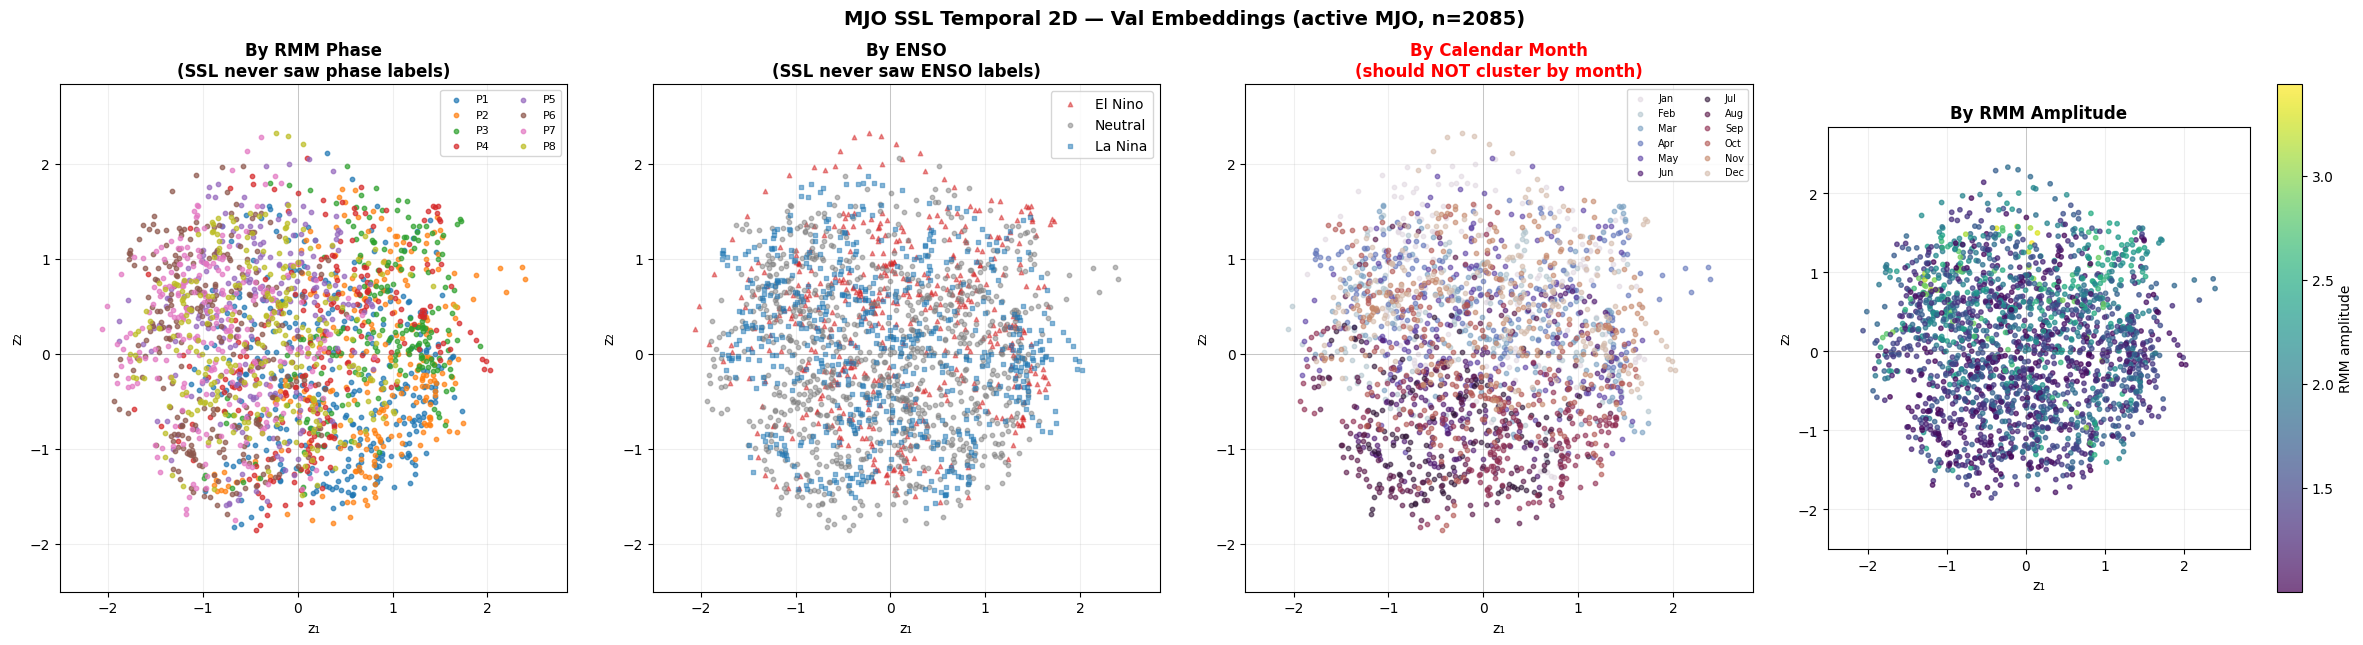

In [ ]:
# Show val active MJO days for clarity
lv = labels_bp.loc[val_idx]
act_v = (~lv['weak_mjo'].values) & (lv['phase'].between(1, 8).values)
Z_val = embeddings_2d[val_idx][act_v]
lv_a  = lv[act_v]

phase_colors = plt.cm.tab10(np.linspace(0, 0.8, 8))
enso_palette = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}
enso_marker  = {'El Nino': '^',       'Neutral': 'o',        'La Nina': 's'}
month_colors = plt.cm.twilight(np.linspace(0, 1, 13))[:12]   # cyclic colors for 12 months
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

rng_lo = min(Z_val.min(), -1.0); rng_hi = max(Z_val.max(), 1.0)
pad = 0.1 * (rng_hi - rng_lo); rng_lo -= pad; rng_hi += pad

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# (a) by RMM phase
ax = axes[0]
for ph in range(1, 9):
    m = lv_a['phase'] == ph
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=[phase_colors[ph-1]], s=10, alpha=0.7, label=f'P{ph}')
ax.set_title('By RMM Phase\n(SSL never saw phase labels)', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.2)

# (b) by ENSO
ax = axes[1]
for cat in ['El Nino', 'Neutral', 'La Nina']:
    m = lv_a['enso_category'] == cat
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=enso_palette[cat], marker=enso_marker[cat], s=10, alpha=0.5, label=cat)
ax.set_title('By ENSO\n(SSL never saw ENSO labels)', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(); ax.grid(alpha=0.2)

# (c) by CALENDAR MONTH — the critical confound check (12 months for all-year MJO)
ax = axes[2]
months = lv_a['date'].dt.month.values
for mi in range(1, 13):
    m = months == mi
    if m.sum() == 0: continue
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=[month_colors[mi-1]], s=10, alpha=0.6, label=month_names[mi-1])
ax.set_title('By Calendar Month\n(should NOT cluster by month)', fontweight='bold', color='red')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='best'); ax.grid(alpha=0.2)

# (d) by amplitude
ax = axes[3]
sc = ax.scatter(Z_val[:, 0], Z_val[:, 1], c=lv_a['amplitude'].values, cmap='viridis', s=10, alpha=0.7)
ax.set_title('By RMM Amplitude', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
plt.colorbar(sc, ax=ax, label='RMM amplitude'); ax.grid(alpha=0.2)

plt.suptitle(f'MJO SSL Temporal 2D — Val Embeddings (active MJO, n={len(Z_val)})',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/embedding_2d_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10b — ENSO Marginal Histograms (El Nino vs La Nina)

Marginal-histogram companion to the ENSO scatter above ([r-bloggers example 8.41](https://www.r-bloggers.com/2011/06/example-8-41-scatterplot-with-marginal-histograms/)):
one density-normalised histogram per ENSO category on each latent axis, so the
El Nino and La Nina **means** can be compared directly instead of eyeballed from
an overplotted cloud. Neutral days are kept as grey background context; all
statistics are El Nino vs La Nina only.

**Three figures:**

1. `enso_marginal_hist.png` — **raw** marginals, pooled over all phases. Answers
   *is the latent cloud as a whole shifted?* This mixes two effects: (i) within a
   phase, EN days sit somewhere different from LN days, and (ii) EN and LN years
   simply spend different amounts of time in each phase.
2. `enso_marginal_residual.png` — same layout after **removing the per-phase
   mean**, so a difference cannot come from unequal phase occupancy. This isolates
   the within-phase displacement — the quantity the ENSO displacement z-score
   measures. The two can disagree: the raw shift can be ~0 while the per-phase
   displacement is large, because displacements at opposite points of the ring
   cancel when pooled.
3. `enso_marginal_polar.png` — the ring's natural coordinates: radius
   (oscillation amplitude) and angle (phase clock).

Caveat for this notebook: the SSL embedding carries a strong calendar-month
confound (month ANOVA F ~ 300, Session 24). An EN-LN separation here can partly
reflect EN and LN peaking in different calendar windows; the year-block bootstrap
does **not** remove that. Read this figure next to the month-confound check below.

**Reading the numbers.** `enso_category` is a per-year JJA Nino-3.4 label and the
fields decorrelate in ~15-25 d, so the independent unit is the **year**, not the day.
The day-level t-test is printed for reference but is over-confident by roughly
sqrt(n_days / n_years); trust the **year-block bootstrap 95% CI** and the year-label
permutation p instead.

`SCOPE = 'all'` (default) uses every day, matching the ENSO-displacement cell these
figures visualise. `SCOPE = 'val'` restricts to held-out years, but the val split is
every 5th year, leaving only ~2-3 El Nino and ~2-3 La Nina years — too few for the
year-level test to resolve anything (the permutation p then has a floor of
1/C(n_EN+n_LN, n_EN)). The cell prints that floor so the limit is visible.


Using the in-memory embeddings.
Scope: all  ->  10042 of 16256 days
MJO SSL Temporal 2D (active MJO):  n=10042 days  (EN 2290, LN 3286, Neutral 4466)
Independent units: 29 El Nino years, 32 La Nina years  -> year-permutation p cannot go below 0.000
Years: EN [np.int32(1979), np.int32(1980), np.int32(1982), np.int32(1983), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1997), np.int32(1998), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2009), np.int32(2010), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2023)]
       LN [np.int32(1981), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1988), np.int32(1989), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2003), np.int32(2005), np.int32(

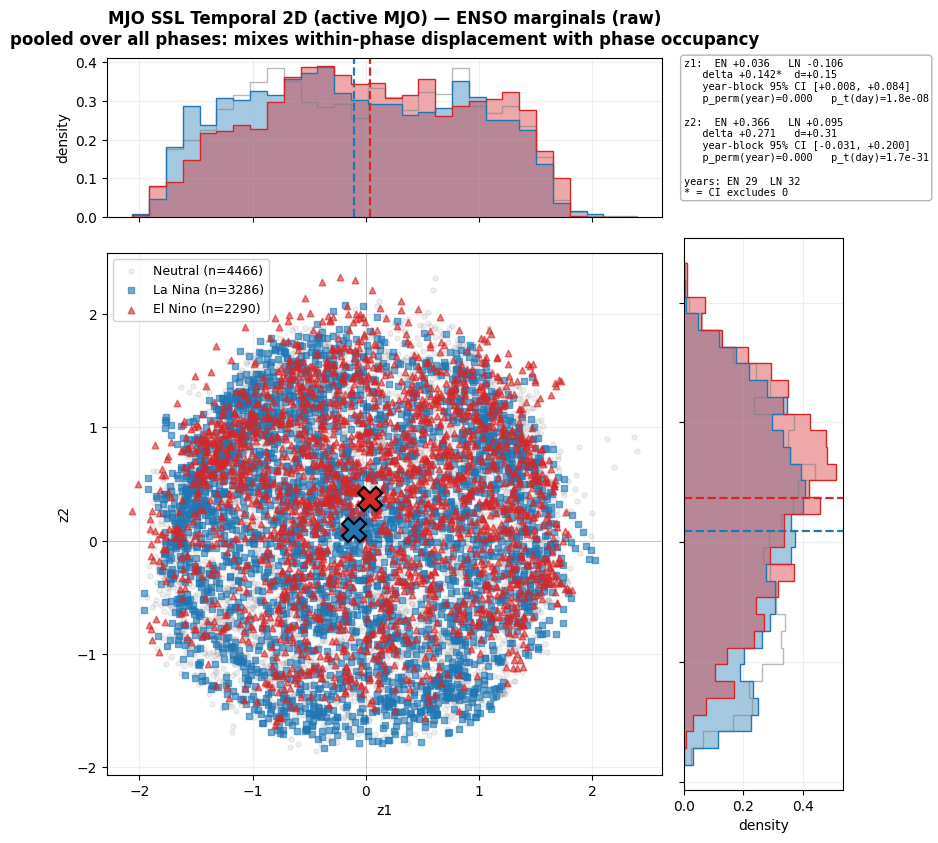

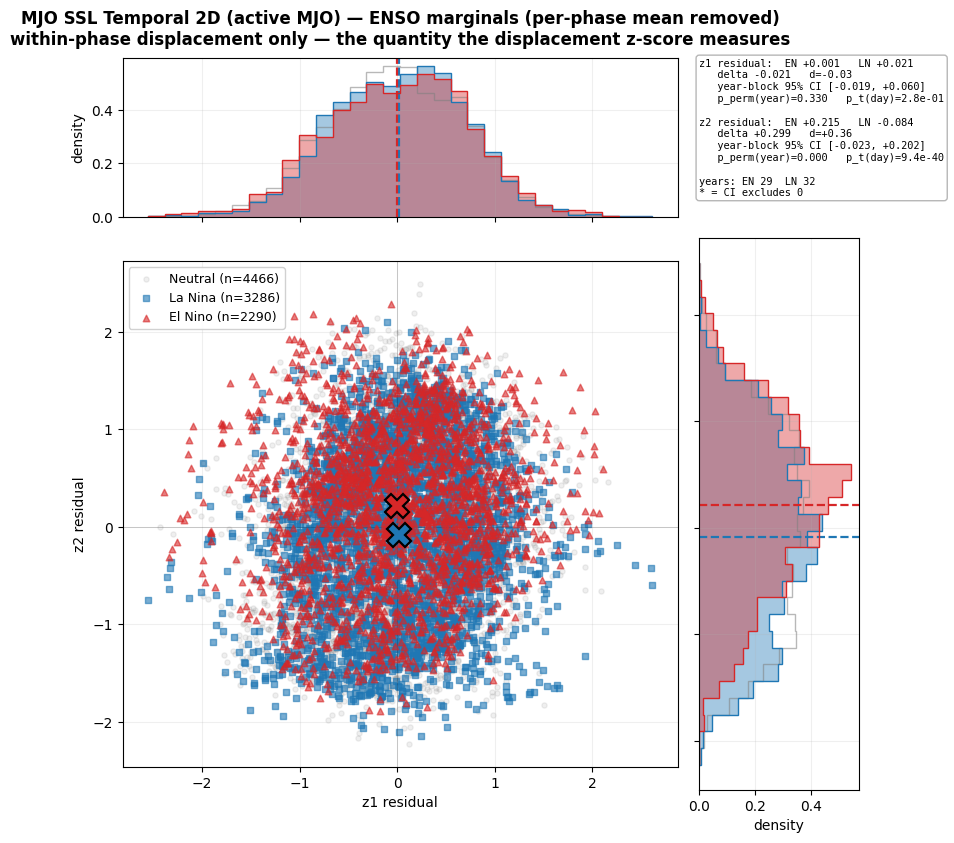

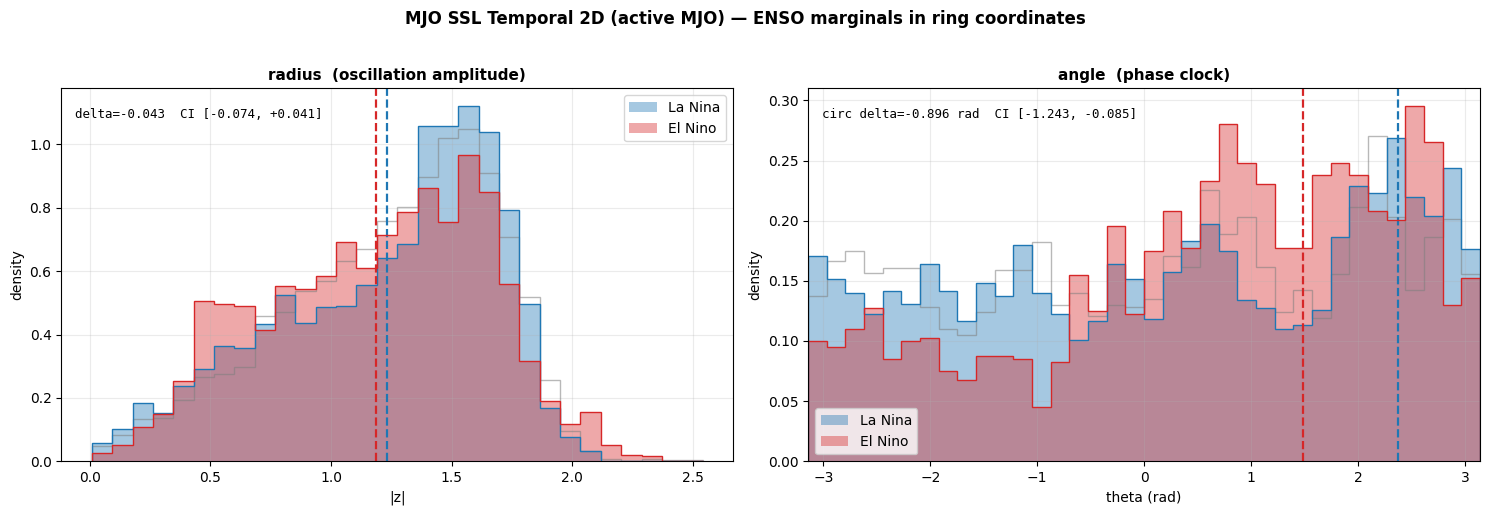


EN - LN mean difference (delta), with year-block 95% CI:
             mean_EN  mean_LN   delta  cohens_d  boot_lo  boot_hi  p_perm_year  p_naive_day
axis                                                                                       
z1_raw        0.0363  -0.1058  0.1421    0.1529   0.0077   0.0843       0.0000       0.0000
z2_raw        0.3663   0.0953  0.2711    0.3134  -0.0307   0.2001       0.0000       0.0000
z1_resid      0.0008   0.0215 -0.0207   -0.0297  -0.0192   0.0596       0.3300       0.2813
z2_resid      0.2155  -0.0838  0.2993    0.3564  -0.0234   0.2016       0.0000       0.0000
r_raw         1.1889   1.2320 -0.0432   -0.0957  -0.0736   0.0411       0.1565       0.0005
theta_raw     1.4820   2.3779 -0.8959       NaN  -1.2431  -0.0851       0.0015       0.0000
r_resid      -0.0365   0.0042 -0.0408   -0.0908  -0.0719   0.0433       0.1765       0.0009
theta_resid   0.0255  -0.0209  0.0464       NaN  -0.0701   0.1825       0.4785       0.2070

NOTE: angular resulta

In [ ]:
# ── ENSO marginal histograms — El Nino vs La Nina  (Session 61) ──────────────
# Pure plotting cell: no GPU, no X, no model, no retraining.
TAG         = 'mjo_ssl'
TITLE       = 'MJO SSL Temporal 2D (active MJO)'
PHASE_COL   = 'phase'
UNIT_CIRCLE = False   # no L2 norm -> radius is a real degree of freedom
SCOPE       = 'all'   # 'all' = every day, matching the ENSO-displacement cell below.
                      # 'val' = held-out years only, but that leaves ~2-3 EN and LN
                      # YEARS, and the year is the independent unit here, so the
                      # year-block CI becomes uninformative. See the printout.
N_BOOT      = 2000
PERSIST_DIR = f'{PROJECT_DIR}/results/enso_marginal'

import os
import numpy as np
import pandas as pd

try:                                    # 1. variables still in memory
    _Zf, _lf = embeddings_2d, labels_bp
    print('Using the in-memory embeddings.')
except NameError:
    _p = f'{RESULTS_DIR}/embeddings.npy'
    if os.path.exists(_p):              # 2. reload what this notebook saved
        _Zf = np.load(_p)
        _lf = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_BP_FILE}', parse_dates=['date'])
        print(f'Reloaded embeddings.npy ({len(_Zf)} rows).')
    else:                               # 3. RESULTS_DIR was cleared -> this cell's cache
        _cache = f'{PERSIST_DIR}/{TAG}_marginal_inputs.npz'
        if not os.path.exists(_cache):
            raise FileNotFoundError(
                'Nothing to plot — no embeddings in memory and none on disk.\n'
                f'  looked for: {_p}\n'
                f'              {_cache}\n'
                'Cause: Cell 1 deletes everything in RESULTS_DIR (and the checkpoint) '
                'when CLEAR_STALE=True, and this cell has never completed a run, so it '
                'has no cache of its own yet.\n'
                'Fix: (a) restore embeddings.npy from Google Drive Trash '
                '(drive.google.com -> Trash -> Restore), or (b) re-run this notebook '
                'from the top with CLEAR_STALE=False to rebuild embeddings.npy, then '
                'run this cell again.')
        _c  = np.load(_cache)
        _Zf = _c['Z']
        _lf = pd.DataFrame({PHASE_COL: _c['phase'], 'enso_category': _c['cat'],
                            'date': pd.to_datetime(_c['year'].astype(str))})  # only .dt.year is used
        SCOPE = 'cache'
        print('Restored from the cached npz written by an earlier run of this cell.')

assert len(_Zf) == len(_lf), f'embeddings {len(_Zf)} vs labels {len(_lf)} mismatch'
if SCOPE == 'val':                      # same split rule as the training cells above
    _m = _lf['date'].dt.year.isin(sorted(_lf['date'].dt.year.unique())[::5]).values
else:
    _m = np.ones(len(_lf), dtype=bool)
if 'weak_mjo' in _lf.columns:   # absent from the tier-3 cache, which is already filtered
    _m &= (~_lf['weak_mjo'].values) & _lf['phase'].between(1, 8).values
Z_m, lab_m = _Zf[_m], _lf.loc[_m]
print(f'Scope: {SCOPE}  ->  {int(_m.sum())} of {len(_lf)} days')

# ── shared body (identical in notebooks 07 / 08 / 14 / 15) ───────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

os.makedirs(PERSIST_DIR, exist_ok=True)

Z_m   = np.asarray(Z_m, dtype=float)
lab_m = lab_m.reset_index(drop=True)
keep  = lab_m[PHASE_COL].between(1, 8).values & np.isfinite(Z_m).all(axis=1)
Z_m, lab_m = Z_m[keep], lab_m.loc[keep].reset_index(drop=True)

cat_m   = lab_m['enso_category'].values
phase_m = lab_m[PHASE_COL].values.astype(int)
year_m  = lab_m['date'].dt.year.values
is_en, is_ln, is_nu = cat_m == 'El Nino', cat_m == 'La Nina', cat_m == 'Neutral'

# Cache inputs so this figure can be regenerated even if RESULTS_DIR is wiped
np.savez(f'{PERSIST_DIR}/{TAG}_marginal_inputs.npz',
         Z=Z_m, phase=phase_m, year=year_m, cat=cat_m.astype('U10'))

from math import comb
_ny_en, _ny_ln = len(np.unique(year_m[is_en])), len(np.unique(year_m[is_ln]))
_p_floor = 1.0 / comb(_ny_en + _ny_ln, _ny_en)
print(f'{TITLE}:  n={len(Z_m)} days  '
      f'(EN {is_en.sum()}, LN {is_ln.sum()}, Neutral {is_nu.sum()})')
print(f'Independent units: {_ny_en} El Nino years, {_ny_ln} La Nina years  '
      f'-> year-permutation p cannot go below {_p_floor:.3f}')
if _p_floor > 0.02:
    print('  WARNING: too few years for the year-level test to resolve significance. '
          "Use SCOPE='all' (or read the bootstrap CI, not the p-value).")
print(f'Years: EN {sorted(np.unique(year_m[is_en]))}')
print(f'       LN {sorted(np.unique(year_m[is_ln]))}')

# ── circular helpers ────────────────────────────────────────────────────────
def _cmean(a):
    return np.arctan2(np.sin(a).mean(), np.cos(a).mean())

def _wrap(a):
    return np.arctan2(np.sin(a), np.cos(a))

def _mean(v, circular):
    return _cmean(v) if circular else v.mean()

def _delta(ve, vl, circular):
    """EN − LN mean difference; smallest signed arc if circular."""
    return _wrap(_cmean(ve) - _cmean(vl)) if circular else ve.mean() - vl.mean()

# ── statistics ──────────────────────────────────────────────────────────────
# ENSO category is a per-year label and the fields decorrelate in ~15-25 d, so
# the independent unit is the YEAR, not the day. Day-level p-values are shown
# for reference only; the year-block bootstrap CI is the honest uncertainty.
def _stats(v, circular, seed=0):
    ve, vl = v[is_en], v[is_ln]
    yr_en, yr_ln = np.unique(year_m[is_en]), np.unique(year_m[is_ln])
    obs = _delta(ve, vl, circular)

    if circular:
        d_pool = np.concatenate([_wrap(ve - _cmean(ve)), _wrap(vl - _cmean(vl))])
        sd_p, cohen = d_pool.std(ddof=1), np.nan
        rng = np.random.default_rng(seed + 7)
        pool = np.concatenate([ve, vl])
        lab_p = np.r_[np.ones(len(ve), bool), np.zeros(len(vl), bool)]
        null = np.empty(1000)
        for i in range(1000):
            s = rng.permutation(lab_p)
            null[i] = abs(_delta(pool[s], pool[~s], True))
        p_naive = float((null >= abs(obs)).mean())
    else:
        sd_p = np.sqrt(((len(ve)-1)*ve.var(ddof=1) + (len(vl)-1)*vl.var(ddof=1))
                       / (len(ve) + len(vl) - 2))
        cohen  = obs / (sd_p + 1e-12)
        p_naive = float(stats.ttest_ind(ve, vl, equal_var=False).pvalue)

    by_year = {y: np.where(year_m == y)[0] for y in np.unique(year_m)}
    rng = np.random.default_rng(seed)

    boot = np.empty(N_BOOT)
    for i in range(N_BOOT):
        se = rng.choice(yr_en, len(yr_en), replace=True)
        sl = rng.choice(yr_ln, len(yr_ln), replace=True)
        boot[i] = _delta(np.concatenate([v[by_year[y]] for y in se]),
                         np.concatenate([v[by_year[y]] for y in sl]), circular)
    if circular:   # percentiles of raw angles wrap; centre on the observed value
        lo, hi = obs + np.percentile(_wrap(boot - obs), [2.5, 97.5])
    else:
        lo, hi = np.percentile(boot, [2.5, 97.5])

    all_yr, k = np.concatenate([yr_en, yr_ln]), len(yr_en)
    null = np.empty(N_BOOT)
    for i in range(N_BOOT):
        s  = rng.permutation(all_yr)
        ie = np.concatenate([by_year[y] for y in s[:k]])
        il = np.concatenate([by_year[y] for y in s[k:]])
        null[i] = _delta(v[ie], v[il], circular)
    p_perm = float((np.abs(null) >= abs(obs)).mean())

    R_en = np.hypot(np.cos(ve).mean(), np.sin(ve).mean()) if circular else np.nan
    R_ln = np.hypot(np.cos(vl).mean(), np.sin(vl).mean()) if circular else np.nan
    return dict(mean_EN=_mean(ve, circular), mean_LN=_mean(vl, circular),
                R_EN=R_en, R_LN=R_ln,
                delta=obs, cohens_d=cohen, sd_pooled=sd_p,
                n_EN_days=int(is_en.sum()), n_LN_days=int(is_ln.sum()),
                n_EN_years=len(yr_en), n_LN_years=len(yr_ln),
                p_naive_day=p_naive, boot_lo=lo, boot_hi=hi, p_perm_year=p_perm)

def _residual(v, circular):
    """Remove the per-phase mean so a difference cannot come from unequal
    phase occupancy between EN and LN years."""
    out = v.astype(float).copy()
    for p in np.unique(phase_m):
        m = phase_m == p
        out[m] = _wrap(v[m] - _cmean(v[m])) if circular else v[m] - v[m].mean()
    return out

# ── figures ─────────────────────────────────────────────────────────────────
EN_C, LN_C, NU_C = '#d62728', '#1f77b4', '#7f7f7f'

def _marginal(ax, v, horiz, bins, circular=False):
    kw = dict(bins=bins, density=True, orientation='horizontal' if horiz else 'vertical')
    ax.hist(v[is_nu], histtype='step', color=NU_C, lw=0.8, alpha=0.55, **kw)
    for m, c, n in [(is_ln, LN_C, 'La Nina'), (is_en, EN_C, 'El Nino')]:
        ax.hist(v[m], histtype='stepfilled', color=c, alpha=0.40, label=n, **kw)
        ax.hist(v[m], histtype='step', color=c, lw=1.4, **kw)
        mu = _cmean(v[m]) if circular else v[m].mean()
        (ax.axhline if horiz else ax.axvline)(mu, color=c, ls='--', lw=1.6)

def _joint(Z, s1, s2, title, fname, xl, yl):
    fig = plt.figure(figsize=(9.5, 9.5))
    gs  = GridSpec(2, 2, width_ratios=[4, 1.15], height_ratios=[1.15, 4],
                   hspace=0.06, wspace=0.06, figure=fig)
    axm = fig.add_subplot(gs[1, 0])
    axt = fig.add_subplot(gs[0, 0], sharex=axm)
    axr = fig.add_subplot(gs[1, 1], sharey=axm)
    axs = fig.add_subplot(gs[0, 1]); axs.axis('off')

    axm.scatter(Z[is_nu, 0], Z[is_nu, 1], c=NU_C, marker='o', s=14, alpha=0.12,
                label=f'Neutral (n={is_nu.sum()})', zorder=1)
    axm.scatter(Z[is_ln, 0], Z[is_ln, 1], c=LN_C, marker='s', s=20, alpha=0.60,
                label=f'La Nina (n={is_ln.sum()})', zorder=2)
    axm.scatter(Z[is_en, 0], Z[is_en, 1], c=EN_C, marker='^', s=22, alpha=0.60,
                label=f'El Nino (n={is_en.sum()})', zorder=3)
    for m, c in [(is_ln, LN_C), (is_en, EN_C)]:
        axm.plot(Z[m, 0].mean(), Z[m, 1].mean(), marker='X', ms=17, mfc=c,
                 mec='k', mew=1.6, ls='none', zorder=4)
    axm.axhline(0, color='k', lw=0.4, alpha=0.3); axm.axvline(0, color='k', lw=0.4, alpha=0.3)
    axm.set_xlabel(xl); axm.set_ylabel(yl); axm.set_aspect('equal')
    axm.grid(alpha=0.2); axm.legend(loc='upper left', fontsize=9, framealpha=0.9)

    b1 = np.histogram_bin_edges(Z[:, 0], bins=30)
    b2 = np.histogram_bin_edges(Z[:, 1], bins=30)
    _marginal(axt, Z[:, 0], False, b1); _marginal(axr, Z[:, 1], True, b2)
    axt.set_ylabel('density'); axr.set_xlabel('density')
    plt.setp(axt.get_xticklabels(), visible=False)
    plt.setp(axr.get_yticklabels(), visible=False)
    axt.grid(alpha=0.2); axr.grid(alpha=0.2)
    axt.set_title(title, fontweight='bold', fontsize=12, pad=10)

    def _line(n, s):
        star = '*' if (s['boot_lo'] > 0) or (s['boot_hi'] < 0) else ' '
        return (f"{n}:  EN {s['mean_EN']:+.3f}   LN {s['mean_LN']:+.3f}\n"
                f"   delta {s['delta']:+.3f}{star}  d={s['cohens_d']:+.2f}\n"
                f"   year-block 95% CI [{s['boot_lo']:+.3f}, {s['boot_hi']:+.3f}]\n"
                f"   p_perm(year)={s['p_perm_year']:.3f}   "
                f"p_t(day)={s['p_naive_day']:.1e}")
    axs.text(0, 1, _line(xl, s1) + '\n\n' + _line(yl, s2) +
             f"\n\nyears: EN {s1['n_EN_years']}  LN {s1['n_LN_years']}"
             "\n* = CI excludes 0",
             transform=axs.transAxes, va='top', ha='left', fontsize=7.4,
             family='monospace',
             bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.95))
    plt.savefig(f'{RESULTS_DIR}/{fname}', dpi=150, bbox_inches='tight')
    plt.savefig(f'{PERSIST_DIR}/{TAG}_{fname}', dpi=150, bbox_inches='tight')
    plt.show()

rows = {}
rows['z1_raw'] = _stats(Z_m[:, 0], False)
rows['z2_raw'] = _stats(Z_m[:, 1], False)
_joint(Z_m, rows['z1_raw'], rows['z2_raw'],
       f'{TITLE} — ENSO marginals (raw)\n'
       'pooled over all phases: mixes within-phase displacement with phase occupancy',
       'enso_marginal_hist.png', 'z1', 'z2')

Z_res = np.column_stack([_residual(Z_m[:, 0], False), _residual(Z_m[:, 1], False)])
rows['z1_resid'] = _stats(Z_res[:, 0], False)
rows['z2_resid'] = _stats(Z_res[:, 1], False)
_joint(Z_res, rows['z1_resid'], rows['z2_resid'],
       f'{TITLE} — ENSO marginals (per-phase mean removed)\n'
       'within-phase displacement only — the quantity the displacement z-score measures',
       'enso_marginal_residual.png', 'z1 residual', 'z2 residual')

# ── radius / angle marginals (the ring's natural coordinates) ───────────────
r_m, th_m = np.hypot(Z_m[:, 0], Z_m[:, 1]), np.arctan2(Z_m[:, 1], Z_m[:, 0])
rows['r_raw']      = _stats(r_m, False)
rows['theta_raw']  = _stats(th_m, True)
rows['r_resid']    = _stats(_residual(r_m, False), False)
rows['theta_resid']= _stats(_residual(th_m, True), True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
_marginal(axes[0], r_m, False, np.histogram_bin_edges(r_m, bins=30))
rt = 'radius (== 1 by construction: L2-normalised encoder — uninformative)' if UNIT_CIRCLE \
     else 'radius  (oscillation amplitude)'
axes[0].set_title(rt, fontweight='bold', color='red' if UNIT_CIRCLE else 'black', fontsize=11)
axes[0].set_xlabel('|z|'); axes[0].set_ylabel('density')
axes[0].legend(); axes[0].grid(alpha=0.25)
s = rows['r_raw']
axes[0].annotate(f"delta={s['delta']:+.3f}  CI [{s['boot_lo']:+.3f}, {s['boot_hi']:+.3f}]",
                 xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9, family='monospace')

_marginal(axes[1], th_m, False, np.linspace(-np.pi, np.pi, 37), circular=True)
axes[1].set_title('angle  (phase clock)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('theta (rad)'); axes[1].set_ylabel('density')
axes[1].set_xlim(-np.pi, np.pi); axes[1].legend(); axes[1].grid(alpha=0.25)
s = rows['theta_raw']
axes[1].annotate(f"circ delta={s['delta']:+.3f} rad  CI [{s['boot_lo']:+.3f}, {s['boot_hi']:+.3f}]",
                 xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9, family='monospace')
plt.suptitle(f'{TITLE} — ENSO marginals in ring coordinates', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/enso_marginal_polar.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{PERSIST_DIR}/{TAG}_enso_marginal_polar.png', dpi=150, bbox_inches='tight')
plt.show()

df_marg = pd.DataFrame(rows).T
df_marg.index.name = 'axis'
df_marg.insert(0, 'representation', TAG)
df_marg.to_csv(f'{RESULTS_DIR}/enso_marginal_stats.csv')
df_marg.to_csv(f'{PERSIST_DIR}/{TAG}_enso_marginal_stats.csv')

print('\nEN - LN mean difference (delta), with year-block 95% CI:')
print(df_marg[['mean_EN', 'mean_LN', 'delta', 'cohens_d',
               'boot_lo', 'boot_hi', 'p_perm_year', 'p_naive_day']].round(4).to_string())
_R = rows['theta_raw']
if min(_R['R_EN'], _R['R_LN']) < 0.10:
    print(f"\nNOTE: angular resultant length is small (EN {_R['R_EN']:.3f}, "
          f"LN {_R['R_LN']:.3f}) — the angles are near-uniform around the ring, so the "
          "circular MEAN of theta is ill-defined. Read theta_resid, not theta_raw.")
sig = df_marg[(df_marg.boot_lo > 0) | (df_marg.boot_hi < 0)].index.tolist()
print(f'\nAxes whose year-block CI excludes 0: {sig if sig else "none"}')
print('Reminder: p_naive_day treats each day as independent and is over-confident '
      'by ~sqrt(n_days/n_years); read the CI and p_perm_year instead.')
print(f'\nSaved to {RESULTS_DIR}/ and {PERSIST_DIR}/: '
      'enso_marginal_hist.png, enso_marginal_residual.png, '
      'enso_marginal_polar.png, enso_marginal_stats.csv')


## Cell 11 — Month-Clustering Confound Check (formal ANOVA)

For all-year MJO with 12 months, this is more stringent than BSISO's 5-month version. Threshold: angle ANOVA F > 50 → strong seasonal confound.

Angle by month  ANOVA: F = 753.98  p = 0.00e+00
Radius by month ANOVA: F = 116.38  p = 0.00e+00


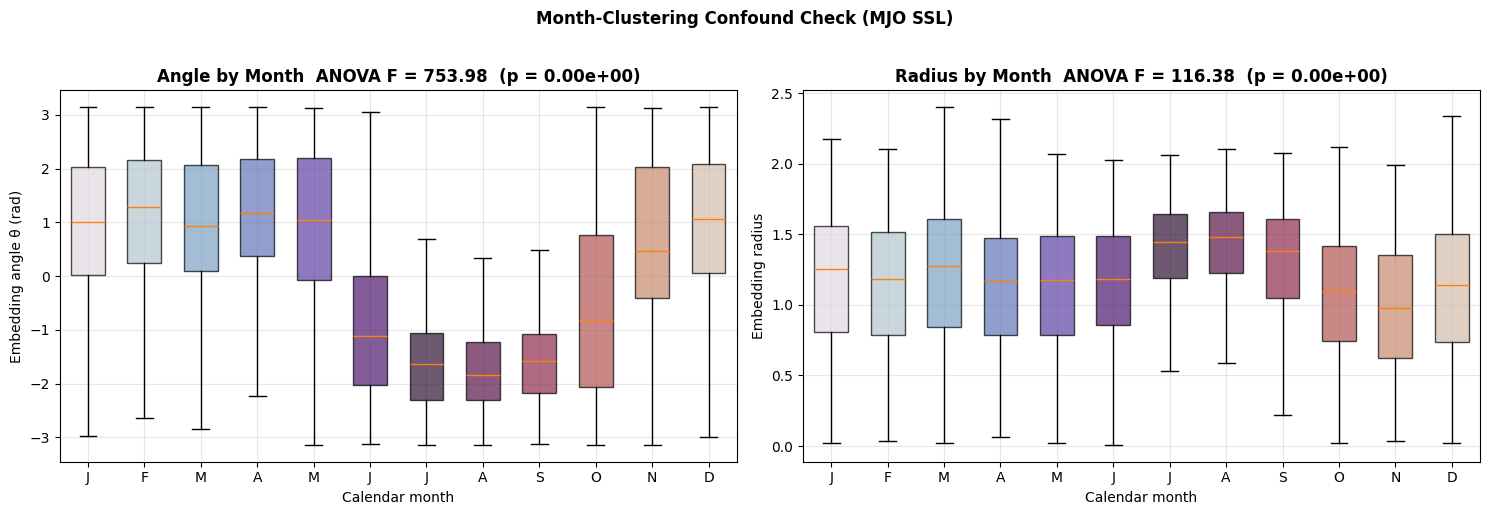


⚠️  Strong month confound on angle (F=754). Bandpass insufficient — consider tightening to (20,60) or restricting negatives to same month.


In [ ]:
from scipy.stats import f_oneway

angles_all = np.arctan2(embeddings_2d[:, 1], embeddings_2d[:, 0])
radii_all  = np.linalg.norm(embeddings_2d, axis=1)
months_all = labels_bp['date'].dt.month.values

angles_by_month = [angles_all[months_all == m] for m in range(1, 13)]
radii_by_month  = [radii_all[months_all == m]  for m in range(1, 13)]

f_a, p_a = f_oneway(*angles_by_month)
f_r, p_r = f_oneway(*radii_by_month)
print(f'Angle by month  ANOVA: F = {f_a:.2f}  p = {p_a:.2e}')
print(f'Radius by month ANOVA: F = {f_r:.2f}  p = {p_r:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
bp = ax.boxplot(angles_by_month, positions=range(1, 13), widths=0.6, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], plt.cm.twilight(np.linspace(0, 1, 13))[:12]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_xlabel('Calendar month'); ax.set_ylabel('Embedding angle θ (rad)')
ax.set_title(f'Angle by Month  ANOVA F = {f_a:.2f}  (p = {p_a:.2e})', fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot(radii_by_month, positions=range(1, 13), widths=0.6, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], plt.cm.twilight(np.linspace(0, 1, 13))[:12]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_xlabel('Calendar month'); ax.set_ylabel('Embedding radius')
ax.set_title(f'Radius by Month  ANOVA F = {f_r:.2f}  (p = {p_r:.2e})', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Month-Clustering Confound Check (MJO SSL)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/month_clustering_check.png', dpi=150, bbox_inches='tight')
plt.show()

if f_a > 50:
    print(f'\n⚠️  Strong month confound on angle (F={f_a:.0f}). Bandpass insufficient — consider tightening to (20,60) or restricting negatives to same month.')
elif f_a > 10:
    print(f'\n△ Moderate month dependence (F={f_a:.1f}). May reflect real intraseasonal amplitude modulation across the annual cycle.')
else:
    print(f'\n✓ Month dependence on angle is weak (F={f_a:.1f}). Confound under control.')

## Cell 12 — Linear Probes (RMM Phase + ENSO Balanced)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, GroupKFold

# Probe over active MJO days only (consistent with how RMM phase is defined)
active_mask = (~labels_bp['weak_mjo'].values) & (labels_bp['phase'].between(1, 8).values)
active_idx = np.where(active_mask)[0]
train_act  = np.intersect1d(train_idx, active_idx)
val_act    = np.intersect1d(val_idx,   active_idx)

Z_train = embeddings_2d[train_act]
Z_val_  = embeddings_2d[val_act]
year_groups_act = labels_bp.loc[active_idx, 'date'].dt.year.values
gkf = GroupKFold(n_splits=5)

# RMM phase
y_tr = labels_bp.loc[train_act, 'phase'].values
y_va = labels_bp.loc[val_act,   'phase'].values
clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(Z_train, y_tr)
phase_val = float(accuracy_score(y_va, clf.predict(Z_val_)))
cv_phase = cross_val_score(clf, embeddings_2d[active_idx], labels_bp.loc[active_idx, 'phase'].values,
                            cv=gkf, groups=year_groups_act, scoring='accuracy', n_jobs=-1)

# ENSO balanced
y_tr_e = labels_bp.loc[train_act, 'enso_category'].values
y_va_e = labels_bp.loc[val_act,   'enso_category'].values
clf_b = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
clf_b.fit(Z_train, y_tr_e)
enso_bal = float(balanced_accuracy_score(y_va_e, clf_b.predict(Z_val_)))
cv_enso = cross_val_score(clf_b, embeddings_2d[active_idx], labels_bp.loc[active_idx, 'enso_category'].values,
                           cv=gkf, groups=year_groups_act, scoring='balanced_accuracy', n_jobs=-1)

probe_results = {
    'RMM Phase': {'val_acc': phase_val,  'cv_mean': float(cv_phase.mean()), 'cv_std': float(cv_phase.std())},
    'ENSO bal':  {'val_acc': enso_bal,   'cv_mean': float(cv_enso.mean()),  'cv_std': float(cv_enso.std())},
}

print('=' * 70)
print('MJO SSL — LINEAR PROBE RESULTS (no labels seen during training)')
print('=' * 70)
print(f'RMM phase val acc:    {phase_val*100:.1f}%   (random 12.5%)')
print(f'RMM phase 5-fold CV:  {cv_phase.mean()*100:.1f}% ± {cv_phase.std()*100:.1f}%')
print(f'ENSO  bal-acc val:    {enso_bal*100:.1f}%   (random 33.3%)')
print(f'ENSO  bal-acc 5-fold: {cv_enso.mean()*100:.1f}% ± {cv_enso.std()*100:.1f}%')
print(f'\nReference (BSISO):')
print(f'  64D supervised:   phase 67.7%, z=3.83')
print(f'  2D supervised:    phase 58.3%, z=2.53')
print(f'  2D SSL temporal:  phase ~30-40%, z=14.55 (key result: ENSO emergence without labels)')

with open(f'{RESULTS_DIR}/linear_probe_results.json', 'w') as f:
    json.dump(probe_results, f, indent=2)

MJO SSL — LINEAR PROBE RESULTS (no labels seen during training)
RMM phase val acc:    23.0%   (random 12.5%)
RMM phase 5-fold CV:  26.6% ± 1.8%
ENSO  bal-acc val:    38.2%   (random 33.3%)
ENSO  bal-acc 5-fold: 37.0% ± 4.5%

Reference (BSISO):
  64D supervised:   phase 67.7%, z=3.83
  2D supervised:    phase 58.3%, z=2.53
  2D SSL temporal:  phase ~30-40%, z=14.55 (key result: ENSO emergence without labels)


## Cell 13 — ENSO Displacement Z-Score

**The headline test:** does ENSO modulation emerge in the SSL embedding without the model being told ENSO categories? If z is large (≥ 5), SSL discovered ENSO-modulated MJO structure from temporal continuity alone — directly parallels the BSISO finding (z=14.55).

EN−LN displacement summary (MJO SSL):
  Observed mean: 0.3898
  Null baseline: 0.0746 ± 0.0136
  Z-score:       23.20
  (BSISO SSL: z=14.55; BSISO supervised 2D: z=2.53)


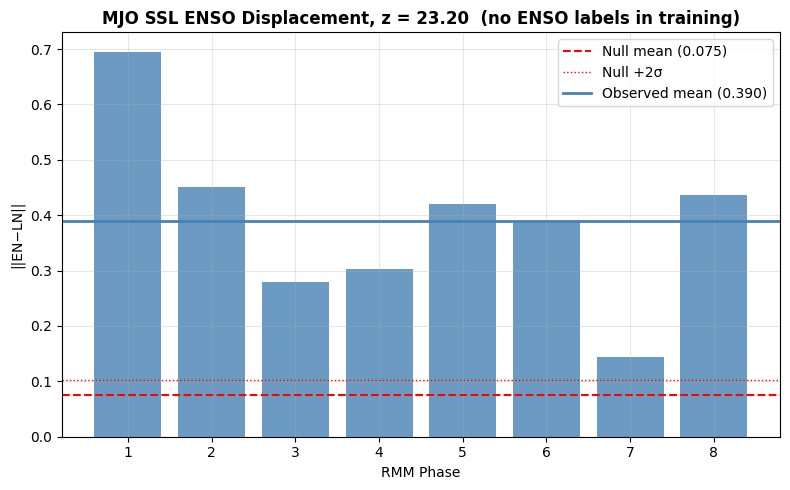

In [ ]:
labels_act = labels_bp.loc[active_mask].reset_index(drop=True)
emb_act = embeddings_2d[active_mask]

phases = range(1, 9)
disp_mag = []
for ph in phases:
    mEN = (labels_act['phase'] == ph) & (labels_act['enso_category'] == 'El Nino')
    mLN = (labels_act['phase'] == ph) & (labels_act['enso_category'] == 'La Nina')
    if mEN.sum() < 3 or mLN.sum() < 3:
        disp_mag.append(np.nan); continue
    cEN = emb_act[mEN].mean(axis=0); cLN = emb_act[mLN].mean(axis=0)
    disp_mag.append(np.linalg.norm(cEN - cLN))

rng = np.random.default_rng(42)
baseline_mag = []
for _ in range(100):
    shuf = labels_act['enso_category'].sample(frac=1, random_state=rng.integers(1e6)).values
    mtrl = []
    for ph in phases:
        mph = (labels_act['phase'] == ph).values
        mEN = mph & (shuf == 'El Nino'); mLN = mph & (shuf == 'La Nina')
        if mEN.sum() < 3 or mLN.sum() < 3: continue
        mtrl.append(np.linalg.norm(emb_act[mEN].mean(axis=0) - emb_act[mLN].mean(axis=0)))
    if mtrl: baseline_mag.append(np.mean(mtrl))

bmu = float(np.mean(baseline_mag)); bsd = float(np.std(baseline_mag))
obs_mu = float(np.nanmean(disp_mag))
z_score_ssl = float((obs_mu - bmu) / (bsd + 1e-8))

print(f'EN−LN displacement summary (MJO SSL):')
print(f'  Observed mean: {obs_mu:.4f}')
print(f'  Null baseline: {bmu:.4f} ± {bsd:.4f}')
print(f'  Z-score:       {z_score_ssl:.2f}')
print(f'  (BSISO SSL: z=14.55; BSISO supervised 2D: z=2.53)')

fig, ax = plt.subplots(figsize=(8, 5))
valid_p = [p for p, m in zip(phases, disp_mag) if not np.isnan(m)]
valid_m = [m for m in disp_mag if not np.isnan(m)]
ax.bar(valid_p, valid_m, color='steelblue', alpha=0.8)
ax.axhline(bmu, color='red', linestyle='--', linewidth=1.5, label=f'Null mean ({bmu:.3f})')
ax.axhline(bmu + 2*bsd, color='red', linestyle=':', linewidth=1, label='Null +2σ')
ax.axhline(obs_mu, color='steelblue', linewidth=2, label=f'Observed mean ({obs_mu:.3f})')
ax.set_xticks(range(1, 9))
ax.set_xlabel('RMM Phase'); ax.set_ylabel('||EN−LN||')
ax.set_title(f'MJO SSL ENSO Displacement, z = {z_score_ssl:.2f}  (no ENSO labels in training)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/enso_displacement.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — MJO SSL Summary + Auto-Decision

In [ ]:
import time as _t

# References for context
BSISO_REF = {
    '64D supervised (BSISO)':         {'phase_val': 0.677, 'phase_cv': '68.6% ± 1.0%', 'enso_bal': 'n/a',  'z': 3.83,  'labels': 'phase + ENSO'},
    '2D supervised (BSISO, nb07c)':   {'phase_val': 0.583, 'phase_cv': '65.7% ± 4.1%', 'enso_bal': '34.6%','z': 2.53,  'labels': 'phase + ENSO'},
    '2D SSL temporal (BSISO, nb08)':  {'phase_val': 0.30,  'phase_cv': '~30-40%',       'enso_bal': '~33%', 'z': 14.55, 'labels': 'none'},
}

rows = []
for name, b in BSISO_REF.items():
    rows.append([name, f"{b['phase_val']*100:.1f}%" if isinstance(b['phase_val'], float) else str(b['phase_val']),
                 b['phase_cv'], str(b['enso_bal']), f"{b['z']:.2f}", b['labels']])
rows.append(['**MJO 2D SSL temporal (this nb)**', f'{phase_val*100:.1f}%',
             f'{cv_phase.mean()*100:.1f}% ± {cv_phase.std()*100:.1f}%',
             f'{enso_bal*100:.1f}%', f'{z_score_ssl:.2f}', '**none (temporal only)**'])
df_comp = pd.DataFrame(rows, columns=['Configuration', 'Phase val', 'Phase CV', 'ENSO bal', 'z-score', 'Labels in training'])

print('=' * 130)
print('MJO SSL SUMMARY — Compared against BSISO References')
print('=' * 130)
print(df_comp.to_string(index=False))

# Auto-decision
month_confound = f_a > 50
phase_pass     = phase_val >= 0.30      # weaker than supervised but well above 12.5% random
z_pass         = z_score_ssl >= 3.0
ssl_advantage  = z_score_ssl > 2.53     # exceeds BSISO supervised baseline
no_signal      = phase_val < 0.20

if month_confound:
    decision = 'MONTH_CONFOUND'
    decision_text = (f"**Seasonal confound detected** (angle ANOVA F={f_a:.1f} > 50). "
                     f"The {BP_LOW_DAYS}–{BP_HIGH_DAYS} d bandpass was insufficient to remove the annual cycle. "
                     f"Recommend: tighten bandpass to (20, 60) d, or restrict negatives to same calendar month.")
elif phase_pass and ssl_advantage:
    decision = 'GREENLIGHT_NB16_KEY_RESULT'
    decision_text = (f"**Key result: SSL captures ENSO modulation more strongly than supervised** "
                     f"(SSL z={z_score_ssl:.2f} > BSISO sup baseline z=2.53). "
                     f"This parallels the BSISO finding and suggests the SSL advantage is a general property "
                     f"of temporal contrastive learning, not specific to boreal summer monsoon dynamics. "
                     f"→ **Greenlight nb16** (three-way comparison: RMM vs supervised vs SSL).")
elif phase_pass and z_pass:
    decision = 'GREENLIGHT_NB16'
    decision_text = (f"SSL discovered some phase + ENSO structure without labels (phase {phase_val*100:.1f}%, z={z_score_ssl:.2f}). "
                     f"Less pronounced SSL advantage than BSISO but still significant. → Greenlight nb16.")
elif no_signal:
    decision = 'NO_SIGNAL'
    decision_text = (f"Temporal continuity alone insufficient (phase {phase_val*100:.1f}% near random). "
                     f"Revisit bandpass design, pair window, or architecture.")
else:
    decision = 'PARTIAL'
    decision_text = (f"Partial signal (phase {phase_val*100:.1f}%, z={z_score_ssl:.2f}). "
                     f"Document and discuss with advisor before nb16.")

print('\n' + '=' * 70)
print(f'DECISION: {decision}')
print('=' * 70)
print(decision_text)

summary = f"""# MJO SSL Temporal 2D Summary

**Auto-generated by notebook 15.**
**Date:** {_t.strftime('%Y-%m-%d')}
**Model:** `encoder_{RUN_TAG}_final.pth`, no L2 norm, τ={TEMPERATURE}, weight_decay={WEIGHT_DECAY}
**Pairs:** anchor d, positive in [d−{MAX_DELTA}, d+{MAX_DELTA}] \\ {{d}}, same year. **No RMM/ENSO labels.**
**Bandpass:** Lanczos {BP_LOW_DAYS}–{BP_HIGH_DAYS} d, half-window {BP_HALF_W} d, edge drop ±{EDGE_DROP_DAYS} d. Result: {len(X_bp)} samples (from {len(X)}).

## Headline comparison

{df_comp.to_markdown(index=False)}

## Month-clustering confound check

- Angle  ANOVA F = {f_a:.2f}  p = {p_a:.2e}
- Radius ANOVA F = {f_r:.2f}  p = {p_r:.2e}
- Threshold: F > 50 = strong confound. {'⚠️  STRONG CONFOUND DETECTED' if f_a > 50 else '✓ confound under control' if f_a < 10 else '△ moderate'}

## Decision

{decision_text}

## Files produced

```
checkpoints/encoder_{RUN_TAG}_final.pth
checkpoints/training_history_{RUN_TAG}.json
data/processed/X_MJO_bp20_90.npy         ({len(X_bp)} samples, bandpassed)
data/processed/labels_aligned_mjo_bp20_90.csv
results/ssl/embeddings.npy
results/ssl/bandpass_filter_response.png
results/ssl/training_curves.png
results/ssl/embedding_2d_overview.png
results/ssl/month_clustering_check.png
results/ssl/linear_probe_results.json
results/ssl/enso_displacement.png
results/ssl/mjo_ssl_summary.md  (this file)
```

## Next

- `16_mjo_comparison.ipynb` — three-way comparison: RMM (conventional) vs supervised (nb14) vs SSL (this nb)
"""

with open(f'{RESULTS_DIR}/mjo_ssl_summary.md', 'w') as f:
    f.write(summary)
print(f'\nSaved: {RESULTS_DIR}/mjo_ssl_summary.md')

MJO SSL SUMMARY — Compared against BSISO References
                    Configuration Phase val     Phase CV ENSO bal z-score       Labels in training
           64D supervised (BSISO)     67.7% 68.6% ± 1.0%      n/a    3.83             phase + ENSO
     2D supervised (BSISO, nb07c)     58.3% 65.7% ± 4.1%    34.6%    2.53             phase + ENSO
    2D SSL temporal (BSISO, nb08)     30.0%      ~30-40%     ~33%   14.55                     none
**MJO 2D SSL temporal (this nb)**     23.0% 26.6% ± 1.8%    38.2%   23.20 **none (temporal only)**

DECISION: MONTH_CONFOUND
**Seasonal confound detected** (angle ANOVA F=754.0 > 50). The 20–90 d bandpass was insufficient to remove the annual cycle. Recommend: tighten bandpass to (20, 60) d, or restrict negatives to same calendar month.

Saved: /content/drive/MyDrive/BSISO_SSL_Project/MJO/results/ssl/mjo_ssl_summary.md


## Cell 15 — (Optional) Download Outputs

In [ ]:
from google.colab import files
for fname in sorted(os.listdir(RESULTS_DIR)):
    files.download(f'{RESULTS_DIR}/{fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Done!

**Send back:**
1. `mjo_ssl_summary.md` — the auto-decision + comparison table
2. `embedding_2d_overview.png` — 4-panel scatter (the by-phase and by-month panels are the key reads)
3. `month_clustering_check.png` — formal confound check
4. `bandpass_filter_response.png` — sanity that the 20–90 d band is what we wanted
5. `training_curves.png` — norms stable, loss converged
6. `enso_displacement.png` — **the key result** (does ENSO modulation emerge without labels?)

Then we proceed to nb16 (three-way comparison).

---
*DDCS Project | jh9141@nyu.edu*